In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv("/content/titanic.csv")

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
from sklearn.impute import SimpleImputer
imp=SimpleImputer(strategy="mean")
df[['Age']]=imp.fit_transform(df[['Age']])
imp=SimpleImputer(strategy="most_frequent")
df[['Cabin']]=imp.fit_transform(df[['Cabin']])
df[['Embarked']]=imp.fit_transform(df[['Embarked']])

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Name']=le.fit_transform(df['Name'])
df['Sex']=le.fit_transform(df['Sex'])
df['Ticket']=le.fit_transform(df['Ticket'])
df['Cabin']=le.fit_transform(df['Cabin'])
df['Embarked']=le.fit_transform(df['Embarked'])

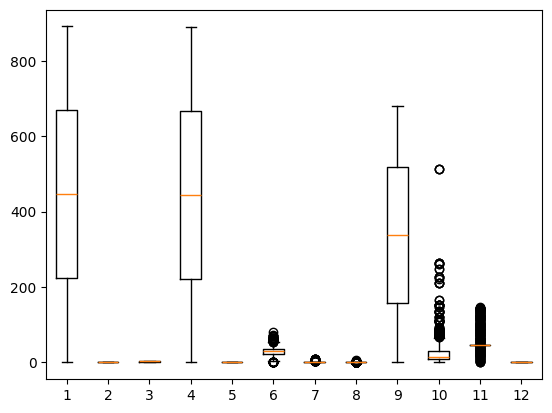

In [ ]:
plt.boxplot(df)
plt.show()

In [ ]:
from scipy.stats.mstats import winsorize
df['Age']=winsorize(df['Age'],limits=[0.10,0.10])
df['SibSp']=winsorize(df['SibSp'],limits=[0.10,0.10])
df['Parch']=winsorize(df['Parch'],limits=[0.15,0.15])
df['Cabin']=winsorize(df['Cabin'],limits=[0.20,0.20])
df['Fare']=winsorize(df['Fare'],limits=[0.15,0.15])

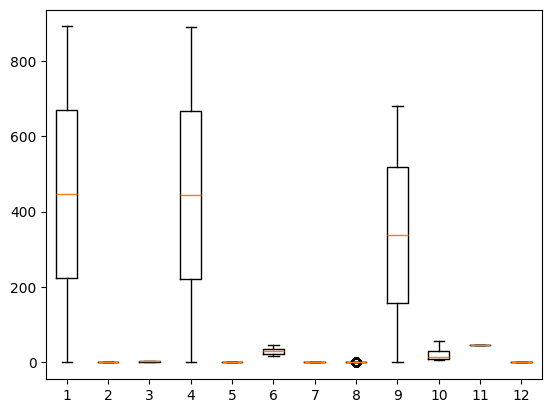

In [ ]:
plt.boxplot(df)
plt.show()

In [ ]:
from sklearn import model_selection
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
x=df.drop('Survived',axis=1)
y=df['Survived']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

model=RandomForestClassifier(n_estimators=100,random_state=42,max_depth=10,min_samples_split=5)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print("Accuracy Score",accuracy_score(y_test,y_pred))


Accuracy Score 0.8324022346368715
